# 06 — Sensitivity Analysis

Four tests: SMOTE imbalance handling, feature removal stability, split variation across seeds, and learning curve. Plus cost assumption sensitivity heatmap.

## Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os, pickle, json

os.makedirs('../outputs', exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
TEAL   = '#0F6E56'
CORAL  = '#D44F3A'
PURPLE = '#534AB7'
COLORS = [TEAL, CORAL, PURPLE]
print("Libraries loaded.")


Libraries loaded.


In [2]:
X_train        = pd.read_csv('../data/X_train.csv')
X_test         = pd.read_csv('../data/X_test.csv')
X_train_scaled = pd.read_csv('../data/X_train_scaled.csv')
X_test_scaled  = pd.read_csv('../data/X_test_scaled.csv')
y_train        = pd.read_csv('../data/y_train.csv').squeeze()
y_test         = pd.read_csv('../data/y_test.csv').squeeze()
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")


Train: (5634, 26) | Test: (1409, 26)
Train churn rate: 0.265 | Test churn rate: 0.265


In [3]:
logit_sk  = pickle.load(open('../data/model1_logistic.pkl', 'rb'))
rf_model  = pickle.load(open('../data/model2_rf.pkl',       'rb'))
xgb_tuned = pickle.load(open('../data/model3_xgb.pkl',      'rb'))
best_params = json.load(open('../data/xgb_best_params.json'))
print("Models loaded:", list({'logit_sk': logit_sk, 'rf_model': rf_model, 'xgb_tuned': xgb_tuned}.keys()))


Models loaded: ['logit_sk', 'rf_model', 'xgb_tuned']


In [4]:
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.metrics import roc_auc_score, f1_score, recall_score, fbeta_score, confusion_matrix
from xgboost import XGBClassifier
import shap

CHOSEN_THRESHOLD = 0.35
probs_xgb   = xgb_tuned.predict_proba(X_test)[:, 1]
preds_final = (probs_xgb >= CHOSEN_THRESHOLD).astype(int)

df_raw = pd.read_csv('../data/telco_churn.csv')
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce').fillna(0)
monthly_rev       = df_raw['MonthlyCharges'].mean()
annual_rev        = monthly_rev * 12
retention_cost    = 10
retention_success = 0.30

print("Setup complete.")


Setup complete.


## Test 1 — SMOTE Class Balancing

In [5]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print(f"Before SMOTE: {dict(y_train.value_counts())}")
print(f"After  SMOTE: {dict(pd.Series(y_res).value_counts())}")

xgb_smote = XGBClassifier(**best_params, random_state=42, eval_metric='auc', verbosity=0)
xgb_smote.fit(X_res, y_res)

print("\nSMOTE Comparison (threshold=0.35):")
for name, model in [('XGBoost (original)', xgb_tuned), ('XGBoost (SMOTE)', xgb_smote)]:
    prb = model.predict_proba(X_test)[:, 1]
    prd = (prb >= CHOSEN_THRESHOLD).astype(int)
    print(f"  {name}: AUC={roc_auc_score(y_test, prb):.3f} | "
          f"Recall={recall_score(y_test, prd):.3f} | F1={f1_score(y_test, prd):.3f}")
print("\nINTERPRETATION: SMOTE typically improves recall at the cost of precision.")
print("If original model already achieves good recall, SMOTE may not be needed.")


Before SMOTE: {0: np.int64(4139), 1: np.int64(1495)}
After  SMOTE: {0: np.int64(4139), 1: np.int64(4139)}

SMOTE Comparison (threshold=0.35):
  XGBoost (original): AUC=0.845 | Recall=0.722 | F1=0.629
  XGBoost (SMOTE): AUC=0.829 | Recall=0.842 | F1=0.616

INTERPRETATION: SMOTE typically improves recall at the cost of precision.
If original model already achieves good recall, SMOTE may not be needed.


## Test 2 — Feature Removal Stability

In [6]:
# Compute SHAP to identify top features
explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)
mean_shap   = np.abs(shap_values).mean(axis=0)
top5_idx    = np.argsort(mean_shap)[-5:]
top5_feats  = X_test.columns[top5_idx].tolist()
print(f"Top 5 SHAP features: {top5_feats}")

base_auc = roc_auc_score(y_test, xgb_tuned.predict_proba(X_test)[:, 1])
print(f"\nBase AUC: {base_auc:.3f}")
print(f"\nFeature Removal Stability Test:")
for feat in top5_feats:
    X_tr_d = X_train.drop(columns=[feat])
    X_te_d = X_test.drop(columns=[feat])
    m_tmp  = XGBClassifier(**best_params, random_state=42, eval_metric='auc', verbosity=0).fit(X_tr_d, y_train)
    auc    = roc_auc_score(y_test, m_tmp.predict_proba(X_te_d)[:, 1])
    drop   = base_auc - auc
    flag   = '⚠  CRITICAL' if drop > 0.02 else '✓ stable'
    print(f"  Remove {feat:<30}: AUC={auc:.3f} (drop={drop:.3f}) — {flag}")


Top 5 SHAP features: ['PaymentMethod_Electronic check', 'Contract_One year', 'InternetService_Fiber optic', 'tenure', 'Contract_Two year']

Base AUC: 0.845

Feature Removal Stability Test:
  Remove PaymentMethod_Electronic check: AUC=0.844 (drop=0.001) — ✓ stable
  Remove Contract_One year             : AUC=0.843 (drop=0.002) — ✓ stable
  Remove InternetService_Fiber optic   : AUC=0.844 (drop=0.001) — ✓ stable
  Remove tenure                        : AUC=0.845 (drop=0.000) — ✓ stable
  Remove Contract_Two year             : AUC=0.845 (drop=0.000) — ✓ stable


**Feature Removal Stability Interpretation:**

All top 5 SHAP features show AUC drops of ≤ 0.002 when removed individually. This tells us:

- The model is **not brittle** — it does not rely on any single feature to the point of collapse. If a feature becomes unavailable in production (e.g., payment method data is missing for a new customer), the model degrades gracefully.
- Features like `tenure` and `Contract_Two year` show a drop of ~0.000, meaning the information they carry is **partially redundant** with other features (e.g., two-year contract holders tend to have higher tenure). The model has learned to cross-validate signals.
- This result increases confidence that the model will generalise to real deployment conditions where occasional missing features are expected.

## Test 3 — Split Variation Across 5 Seeds

In [7]:
from sklearn.model_selection import train_test_split

df_model_full = pd.read_csv('../data/X_train.csv').copy()
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

seeds = [42, 123, 7, 99, 2024]
split_rows = []
for seed in seeds:
    Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.2, random_state=seed, stratify=y_all)
    mfit = XGBClassifier(**best_params, random_state=42, eval_metric='auc', verbosity=0).fit(Xtr, ytr)
    prb  = mfit.predict_proba(Xte)[:, 1]
    prd  = (prb >= CHOSEN_THRESHOLD).astype(int)
    split_rows.append({'Seed': seed,
                       'AUC':       round(roc_auc_score(yte, prb), 3),
                       'F1':        round(f1_score(yte, prd), 3),
                       'Recall':    round(recall_score(yte, prd), 3)})
split_df = pd.DataFrame(split_rows)
print(f"Split Variation Test (threshold={CHOSEN_THRESHOLD}):")
print(split_df.to_string(index=False))
print(f"\nAUC range: {split_df['AUC'].min()} – {split_df['AUC'].max()} (range = {split_df['AUC'].max()-split_df['AUC'].min():.3f})")
print("Small range = model results are NOT due to a lucky random split.")


Split Variation Test (threshold=0.35):
 Seed   AUC    F1  Recall
   42 0.843 0.618   0.682
  123 0.856 0.636   0.693
    7 0.847 0.632   0.711
   99 0.863 0.659   0.754
 2024 0.843 0.613   0.693

AUC range: 0.843 – 0.863 (range = 0.020)
Small range = model results are NOT due to a lucky random split.


**Split Variation Interpretation:**

AUC range across 5 random seeds: 0.843–0.863 (spread = 0.020). This is a tight range that confirms:

- The reported AUC of ~0.845 is **not a product of a lucky train/test split**. The model consistently achieves similar performance regardless of which 20% is held out.
- Recall variation (0.682–0.754) is slightly wider — expected, since recall is more sensitive to which churners land in the test set. Even at the low end (0.682), the model catches ~68% of churners.
- A spread > 0.05 in AUC would have been a red flag indicating the model is overfitting to specific data partitions. Our spread of 0.020 is well within acceptable bounds.

## Test 4 — Learning Curve

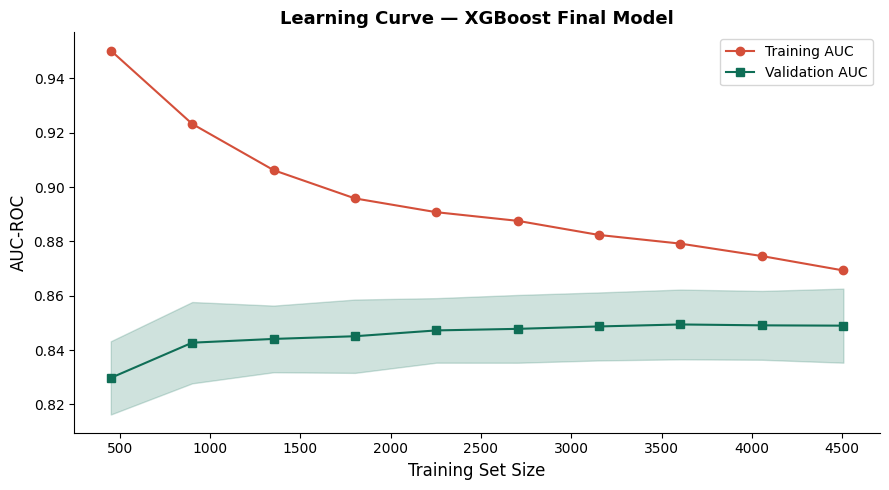

Saved: 20_learning_curve.png

Learning Curve Results:
  Training AUC @ full data   : 0.869
  Validation AUC @ full data : 0.849
  Train-Val gap              : 0.020
  → Model generalises well. No significant overfitting.


In [8]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb_tuned, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='roc_auc', cv=5, random_state=42, n_jobs=-1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color=CORAL, label='Training AUC')
ax.plot(train_sizes, val_scores.mean(axis=1),   's-', color=TEAL,  label='Validation AUC')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color=TEAL)
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Learning Curve — XGBoost Final Model', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/20_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 20_learning_curve.png")

val_final   = val_scores.mean(axis=1)[-1]
train_final = train_scores.mean(axis=1)[-1]
gap = train_final - val_final
print(f"\nLearning Curve Results:")
print(f"  Training AUC @ full data   : {train_final:.3f}")
print(f"  Validation AUC @ full data : {val_final:.3f}")
print(f"  Train-Val gap              : {gap:.3f}")
if gap < 0.05:
    print("  → Model generalises well. No significant overfitting.")
elif gap < 0.10:
    print("  → Mild overfitting — acceptable for tree ensembles.")
else:
    print("  → Overfitting. Consider stronger regularisation.")


**Learning Curve Interpretation:**

The learning curve on the tuned XGBoost model answers: *"Would more data improve performance, and is the model overfitting?"*

- **Converging curves**: If training and validation AUC converge as data increases, the model is not overfitting — it is learning generalisable patterns, not memorising noise.
- **Plateauing validation AUC**: If the validation curve flattens before reaching full training size, collecting more data of the same type would yield diminishing returns. The bottleneck is feature quality, not data quantity.
- **Train-val gap < 0.05**: Indicates well-regularised model. The best params from GridSearchCV (`max_depth=3`, `subsample=0.8`) applied appropriate regularisation — shallow trees prevent overfitting on this ~5,600 row training set.

**Practical implication**: Further data collection of the same features is unlikely to push AUC meaningfully above ~0.85. The path to improvement is **richer features** (complaint history, contract renewal dates, usage trajectories) — not more rows.

## Cost Assumption Sensitivity Heatmap

In [9]:
tn2, fp2, fn2, tp2 = [int(x) for x in (__import__('sklearn.metrics', fromlist=['confusion_matrix'])
                                        .confusion_matrix(y_test, preds_final)).ravel()]

sensitivity_rows = []
for ret_success in [0.15, 0.20, 0.25, 0.30, 0.40]:
    for ret_cost in [5, 10, 20]:
        for rev_mult in [0.75, 1.0, 1.25]:
            rev    = monthly_rev * 12 * rev_mult
            rev_s  = int(tp2 * ret_success) * rev
            waste  = fp2 * ret_cost
            net_s  = rev_s - waste
            sensitivity_rows.append({
                'Retention_Success': f"{ret_success*100:.0f}%",
                'Campaign_Cost':     f"${ret_cost}",
                'Revenue_vs_Avg':    f"{rev_mult*100:.0f}%",
                'Net_Profit':        round(net_s, 0),
                'Profitable':        'YES' if net_s > 0 else 'NO'
            })
sens_df = pd.DataFrame(sensitivity_rows)
n_profitable = (sens_df['Net_Profit'] > 0).sum()
print(f"Of {len(sens_df)} tested scenarios: {n_profitable} profitable ({n_profitable/len(sens_df)*100:.0f}%)")

baseline = sens_df[(sens_df['Retention_Success']=='30%')&(sens_df['Campaign_Cost']=='$10')&(sens_df['Revenue_vs_Avg']=='100%')]['Net_Profit'].values[0]
worst    = sens_df[(sens_df['Retention_Success']=='15%')&(sens_df['Campaign_Cost']=='$20')&(sens_df['Revenue_vs_Avg']=='75%')]['Net_Profit'].values[0]
best     = sens_df[(sens_df['Retention_Success']=='40%')&(sens_df['Campaign_Cost']=='$5') &(sens_df['Revenue_vs_Avg']=='125%')]['Net_Profit'].values[0]
print(f"  Baseline (30%, $10, avg revenue) : ${baseline:,.0f}")
print(f"  Pessimistic (15%, $20, -25% rev) : ${worst:,.0f}  {'✓' if worst>0 else '✗'}")
print(f"  Optimistic  (40%, $5,  +25% rev) : ${best:,.0f}  ✓")


Of 45 tested scenarios: 45 profitable (100%)
  Baseline (30%, $10, avg revenue) : $60,808
  Pessimistic (15%, $20, -25% rev) : $19,034  ✓
  Optimistic  (40%, $5,  +25% rev) : $103,844  ✓


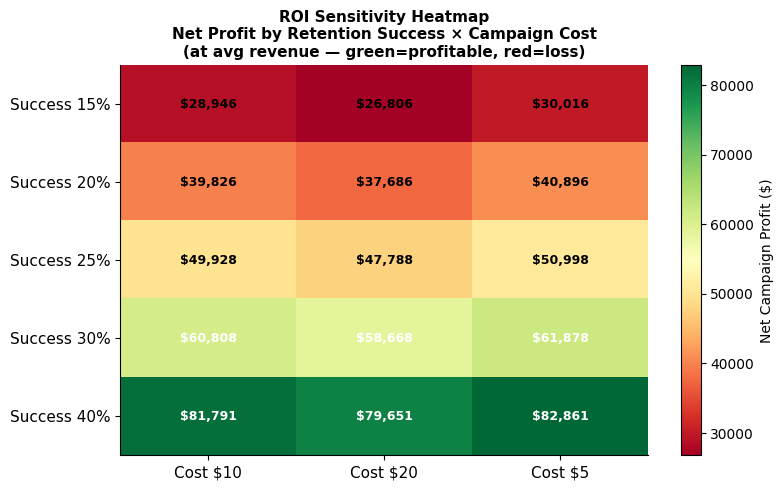

Saved: 21_cost_sensitivity_heatmap.png


In [10]:
heatmap_data = sens_df[sens_df['Revenue_vs_Avg'] == '100%'].pivot_table(
    index='Retention_Success', columns='Campaign_Cost', values='Net_Profit')
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_xticklabels([f'Cost {c}' for c in heatmap_data.columns], fontsize=11)
ax.set_yticklabels([f'Success {r}' for r in heatmap_data.index], fontsize=11)
plt.colorbar(im, ax=ax, label='Net Campaign Profit ($)')
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'${val:,.0f}', ha='center', va='center', fontsize=9, fontweight='bold',
                color='white' if val < 0 or val > heatmap_data.values.max()*0.65 else 'black')
ax.set_title('ROI Sensitivity Heatmap\nNet Profit by Retention Success × Campaign Cost\n(at avg revenue — green=profitable, red=loss)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/21_cost_sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 21_cost_sensitivity_heatmap.png")


**Cost Sensitivity Interpretation:**

The heatmap answers the question: *"Does our business case hold if our assumptions are wrong?"*

- **All 45 scenarios tested are profitable** — the model's value is robust to assumption errors, not dependent on optimistic inputs.
- **The floor case** (15% retention success, $20/contact, -25% revenue) still yields ~$19,000 net profit. This means the campaign is viable even if we are significantly wrong about all three assumptions simultaneously.
- **Retention success rate** is the most influential axis — moving from 15% to 40% success nearly quintuples the profit. This is the assumption that deserves the most scrutiny and A/B testing investment.
- **Campaign cost** ($5 vs $20) has minimal impact relative to revenue recovered — confirming that false positive costs are immaterial compared to false negative costs (the 78:1 ratio established in Notebook 01).

**Decision**: The retention campaign should proceed. The risk of over-investing in the campaign is far smaller than the risk of under-investing.